<a href="https://colab.research.google.com/github/alessiomartini/learning_econophysics/blob/main/Fractional_Brownian_motion_(fBM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 : Fractional Brownian motion (fBM)

from:
Tutorial 1: Time series simulation and analysis
ECO 586/PHY 560C
Modelling Financial Markets:
an Introduction to Econophysics
MICHAEL BENZAQUEN

The fractional Brownian Motion, introduced by Mandelbrot & van Ness in 1968, is a Gaussian
process satisfying
〈xH (t)xH (s)〉 =
1
2
(|t|
2H + |s|
2H − |t − s|
2H
), t,s > 1 . (9.7)
The parameter H is called the Hurst exponent and controls the "roughness" of the process, H = 1/2
corresponding to the standard brownian motion.


In [ ]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv

1. Let L be a T × T matrix. Show that the correlation matrix of the vector y = Lx, where x is an
iid. gaussian vector of size T, is given by C = LL>.


In [ ]:
# C_{ij} = <Y_i Y_j> - <Y_i><Y_j> = <L_{ia} X_a L_{jb} X_b> - <L_{ia} X_a><L_{jb} X_b> = L_{ia} L_{jb} < X_a  X_b> - L_{ia} L_{jb} < X_a>< X_b> = L_{ia} L_{ja} = L @ L^T

2. Define a function C(i,j,H) giving the Ci j term of the correlation matrix of an fBM with exponent
H. In Python, compute the matrix for an fBM of length T = 1000 and the exponent of your choice.
Use the Cholesky decomposition with np.linalg.cholesky to generate a fractional brownian
motion, rescaled as
x˜H (t) = 1/T
H
xH (t) (9.8)
so that all simulated curves have roughly the same scale.



In [ ]:
def C(i,j,H):
  # Shift indices by 1 to avoid t=0 where the formula leads to a singular matrix
  # and also to respect the problem statement's t,s > 1 (or >= 1) implicit condition for the formula.
  return 0.5*(pow(abs(i+1), 2*H) + pow(abs(j+1), 2*H) - pow(abs(i-j), 2*H))

T = 1000
hurst_exponent = 0.7 # Define the Hurst exponent here, e.g., 0.7
correlation_matrix = np.zeros((T,T)) # Renamed C to correlation_matrix to avoid conflict
for i in range(T):
  for j in range(T):
    correlation_matrix[i][j]= C(i,j,hurst_exponent) # Pass the correct hurst_exponent

# print(correlation_matrix)

L = np.linalg.cholesky(correlation_matrix) # Cholesky decomposition, we obtail L from first excercise
Y = np.random.normal(0, 1, (T, 1))
X = L @ Y
rescaled_X = 1/pow(T, hurst_exponent) * X

# print(rescaled_X)

3. Group everything into a function gen_fbm(T,H) that returns an instance of a (rescaled) fBM
with exponent H of length T. Plot for H = 0.25, 0.5, 0.75. Comments?


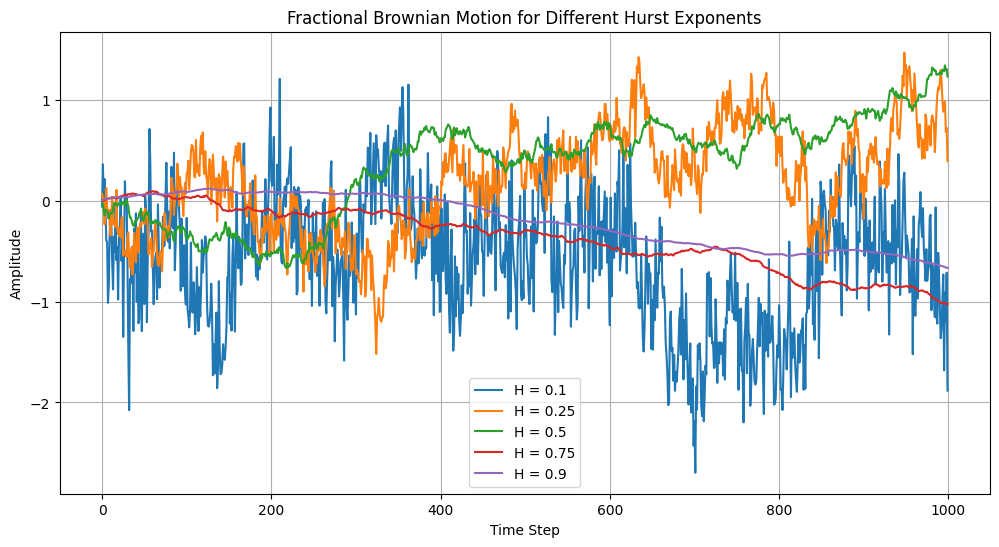

In [ ]:
def gen_fbm(T, H):
  correlation_matrix = np.zeros((T,T))
  for i in range(T):
    for j in range(T):
      correlation_matrix[i][j]= C(i,j,H) # Use H from function argument

  L = np.linalg.cholesky(correlation_matrix)
  Y = np.random.normal(0, 1, (T, 1))
  X = L @ Y
  rescaled_X = 1/pow(T, H) * X

  return rescaled_X

# Define parameters
T = 1000

# Generate and plot fBM for different Hurst exponents
h_values = [0.1, 0.25, 0.5, 0.75, 0.9]

plt.figure(figsize=(12, 6))
for H in h_values:
  fbm_instance = gen_fbm(T, H)
  plt.plot(fbm_instance, label=f'H = {H}')

plt.title('Fractional Brownian Motion for Different Hurst Exponents')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

The main comment is: a bigger hurst_exponent implies smaller volatility/oscillations/2pt function

4. To generate statistics over the fBM process it is necessary to generate many instances of it. Define
now a function gen_N_fbm(T,N,H) that returns a T ×N array with N instances of the fractional
brownian motion for the same exponent H.


In [ ]:
def gen_N_fbm(T, N, H):
  # Initialize an empty list to store N instances of fBM
  fbm_instances = []
  for _ in range(N):
    # Generate one instance of fBM using the previously defined gen_fbm function
    instance = gen_fbm(T, H)
    fbm_instances.append(instance)
  # Concatenate the instances along a new axis to form a T x N array
  return np.concatenate(fbm_instances, axis=1)



5. Create a DataFrame df with 100 columns, each containing a realisation of the fBM with H = 0.3
and T = 1000.


DataFrame 'df' created with shape: (1000, 100)
First 5 rows of df:
         0         1         2         3         4         5         6   \
0  0.031816 -0.093874  0.069595  0.101678 -0.110660  0.194415 -0.008589   
1 -0.024295 -0.159784  0.272079  0.152454 -0.085392  0.229497 -0.079437   
2 -0.112199 -0.271645  0.165120  0.265866 -0.240952  0.220061  0.087915   
3  0.216156 -0.424212 -0.000083  0.337494 -0.298528  0.124207  0.024265   
4 -0.060422 -0.398361  0.103267  0.400679 -0.214858  0.143402 -0.098981   

         7         8         9   ...        90        91        92        93  \
0 -0.120925 -0.073709 -0.104934  ...  0.028310 -0.057917  0.159745 -0.019705   
1  0.060366 -0.225053 -0.047389  ...  0.101629 -0.036080 -0.081373  0.003764   
2  0.010714 -0.361347  0.146135  ...  0.113814 -0.101931  0.243088 -0.089501   
3 -0.100109 -0.239006  0.204233  ...  0.142442  0.017093  0.022353 -0.047932   
4  0.085318 -0.088911  0.262297  ...  0.152409  0.034279  0.104577 -0.076094   

 

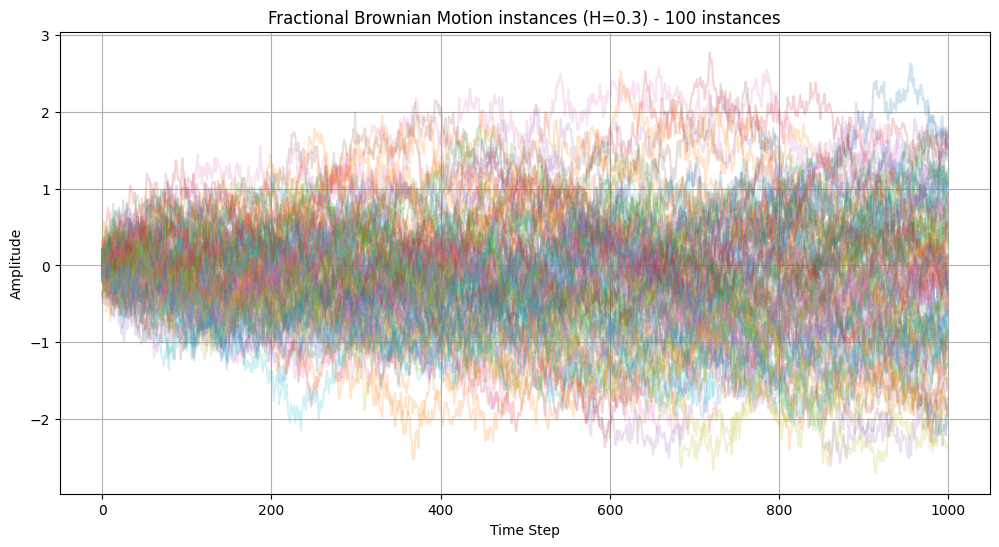

In [ ]:
N_instances = 100
T_length = 1000
H_exponent = 0.3
multiple_fbm = gen_N_fbm(T_length, N_instances, H_exponent)

df = pd.DataFrame(multiple_fbm)
print(f"DataFrame 'df' created with shape: {df.shape}")
# print(f"First 5 rows of df:\n{df.head()}")

# --- Plotting fBM instances ---
plt.figure(figsize=(12, 6))
# Plot each column of multiple_fbm, where each column is an fBM instance
for k in range(N_instances): # Iterate N_instances times, from 0 to N_instances-1
  plt.plot(multiple_fbm[:, k], alpha=0.2) # Plot k-th column, alpha for transparency

plt.title(f'Fractional Brownian Motion instances (H={H_exponent}) - {N_instances} instances')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
# plt.legend() # Omit legend for many plots to avoid clutter
plt.grid(True)
plt.show()

6. Create a function that computes the value (x(t) − x(t + τ))2
, averages it over t for a given
realization, and then averages over all of th realisations in d for a single value τ. Use it to
compute the variogram,
V(τ) =

(x(t + τ) − x(t))2

(9.9)
for 0 ≤ τ < 500.


In [ ]:
def compute_variogram(df, tau):
  # Initialize a list to store the average squared differences for each realization
  squared_diffs_per_realization = []

  # Iterate over each column (realization) in the DataFrame
  for col_name in df.columns:
    realization = df[col_name].values
    # Ensure tau is less than the length of the realization
    if tau >= len(realization):
      continue # Skip if tau is too large for this realization

    # Compute (x(t + tau) - x(t))^2 for valid t values
    # t goes from 0 to len(realization) - tau - 1
    diffs = realization[tau:] - realization[:-tau]
    squared_diffs = diffs**2

    # Average over t for the current realization
    if len(squared_diffs) > 0:
      squared_diffs_per_realization.append(np.mean(squared_diffs))

  # Average over all realizations
  if len(squared_diffs_per_realization) > 0:
    return np.mean(squared_diffs_per_realization)
  else:
    return np.nan # Return NaN if no valid calculations were made

# Compute the variogram for 0 < tau <= 1000
max_tau = 1000
tau_values = np.arange(1, max_tau)
variogram_values = []

for tau in tau_values:
  V_tau = compute_variogram(df, tau)
  variogram_values.append(V_tau)

# Convert to numpy array for easier plotting/analysis
variogram_values = np.array(variogram_values)

print(f"Variogram computed for {len(variogram_values)} tau values.")
# print(f"First 10 variogram values: {variogram_values[:10]}")

Variogram computed for 999 tau values.


7. Plot the results alongside the theoretical value V(τ) ∝ τ
2H
. Do the same for H = 0.75 and
compare.
87
88 TUTORIALS


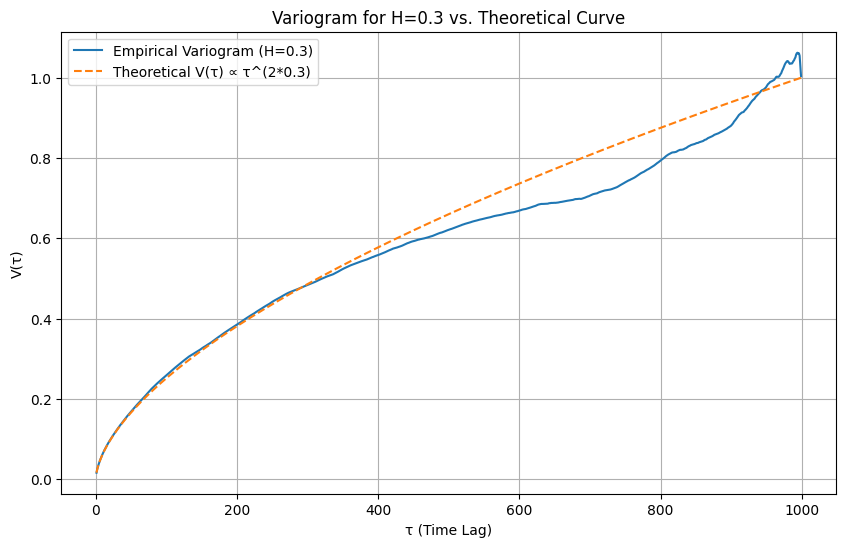

In [ ]:
# For H = 0.3 (using the previously generated df)

# Theoretical variogram: V(τ) ∝ τ^(2H)

plt.figure(figsize=(10, 6))
plt.plot(tau_values, variogram_values, label=f'Empirical Variogram (H={H_exponent})')

# Calculate theoretical curve
theoretical_H03 = tau_values**(2 * H_exponent)

# Normalize theoretical curve to match the scale of the empirical one
# We take a non-zero tau to avoid division by zero if theoretical_H03[0] is 0.
if len(tau_values) > 1 and theoretical_H03[1] != 0:
  # Find a non-zero variogram value to scale, avoiding issues at tau=0
  first_non_zero_idx = np.where(variogram_values > 0)[0]
  if len(first_non_zero_idx) > 0:
    idx_to_scale = first_non_zero_idx[0]
    # If the first non-zero index is 0, shift it to 1 to avoid theoretical_H03[0] = 0^x
    if idx_to_scale == 0 and len(variogram_values) > 1:
        idx_to_scale = 1
    scaling_factor_H03 = variogram_values[idx_to_scale] / theoretical_H03[idx_to_scale]
  else:
    scaling_factor_H03 = 1 # Fallback if all empirical values are zero
else:
  scaling_factor_H03 = 1 # Fallback, if tau_values is too short or theoretical is zero

# Handle potential NaN values from compute_variogram if present
valid_tau_indices = ~np.isnan(variogram_values)
plt.plot(tau_values[valid_tau_indices], scaling_factor_H03 * theoretical_H03[valid_tau_indices], linestyle='--', label=f'Theoretical V(τ) ∝ τ^(2*{H_exponent})')

plt.title(f'Variogram for H={H_exponent} vs. Theoretical Curve')
plt.xlabel('τ (Time Lag)')
plt.ylabel('V(τ)')
plt.legend()
plt.grid(True)
plt.show()

DataFrame 'df_H075' created with shape: (1000, 100) (for H=0.75)
Variogram computed for 999 tau values for H=0.75.


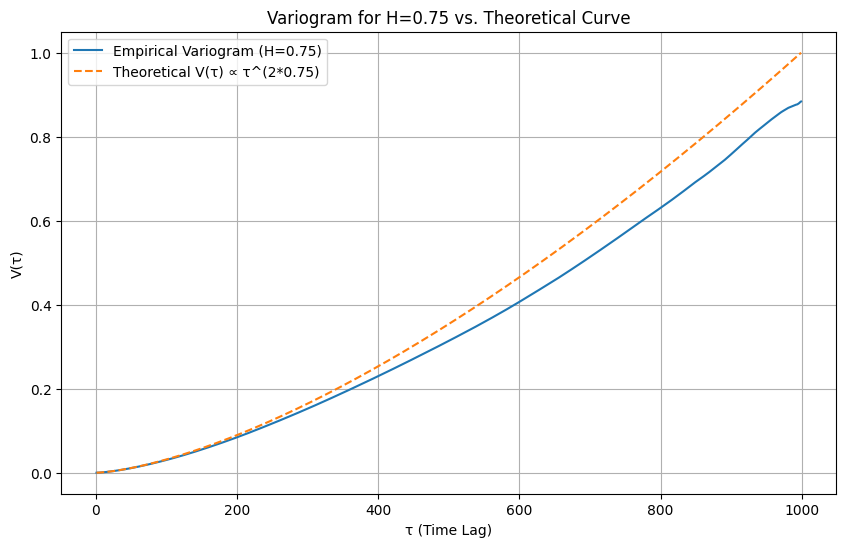

In [ ]:
#### Now, let's repeat the process for H = 0.75

# Generate new fBM instances for H = 0.75
H_exponent_H075 = 0.75
multiple_fbm_H075 = gen_N_fbm(T_length, N_instances, H_exponent_H075)
df_H075 = pd.DataFrame(multiple_fbm_H075)

print(f"DataFrame 'df_H075' created with shape: {df_H075.shape} (for H={H_exponent_H075})")

# Compute the variogram for H = 0.75
variogram_values_H075 = []
for tau in tau_values:
  V_tau_H075 = compute_variogram(df_H075, tau)
  variogram_values_H075.append(V_tau_H075)

variogram_values_H075 = np.array(variogram_values_H075)
print(f"Variogram computed for {len(variogram_values_H075)} tau values for H={H_exponent_H075}.")

plt.figure(figsize=(10, 6))
plt.plot(tau_values, variogram_values_H075, label=f'Empirical Variogram (H={H_exponent_H075})')

# Calculate theoretical curve for H = 0.75
theoretical_H075 = tau_values**(2 * H_exponent_H075)

# Normalize theoretical curve
if len(tau_values) > 1 and theoretical_H075[1] != 0:
  first_non_zero_idx_H075 = np.where(variogram_values_H075 > 0)[0]
  if len(first_non_zero_idx_H075) > 0:
    idx_to_scale_H075 = first_non_zero_idx_H075[0]
    if idx_to_scale_H075 == 0 and len(variogram_values_H075) > 1:
        idx_to_scale_H075 = 1
    scaling_factor_H075 = variogram_values_H075[idx_to_scale_H075] / theoretical_H075[idx_to_scale_H075]
  else:
    scaling_factor_H075 = 1
else:
  scaling_factor_H075 = 1

valid_tau_indices_H075 = ~np.isnan(variogram_values_H075)
plt.plot(tau_values[valid_tau_indices_H075], scaling_factor_H075 * theoretical_H075[valid_tau_indices_H075], linestyle='--', label=f'Theoretical V(τ) ∝ τ^(2*{H_exponent_H075})')

plt.title(f'Variogram for H={H_exponent_H075} vs. Theoretical Curve')
plt.xlabel('τ (Time Lag)')
plt.ylabel('V(τ)')
plt.legend()
plt.grid(True)
plt.show()

COMMENT: H<0.5 is subdiffusive, while H>0.5 is superdiffusive

8. Compute the volatility signature plots V(τ)/τ for the two fBMs you generated and compare.
Comments?

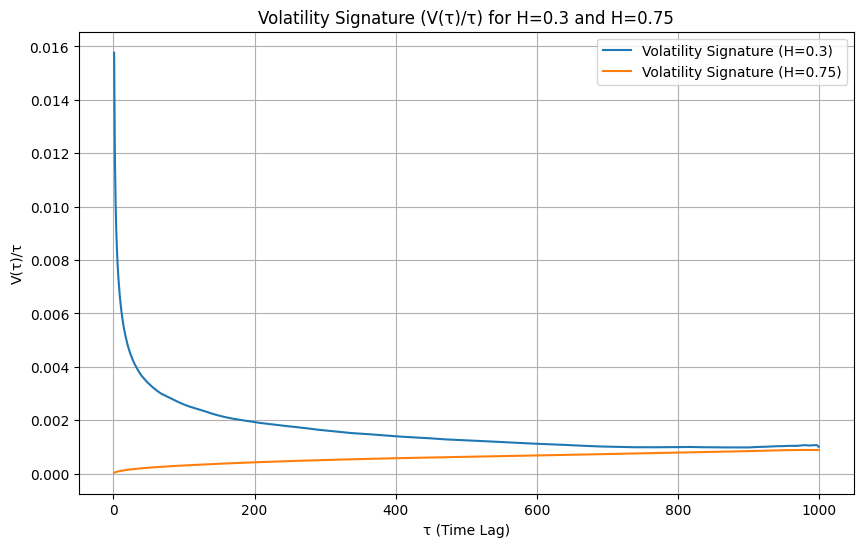

In [ ]:
# Compute volatility signature for H = 0.3
volatility_signature_H03 = variogram_values / tau_values

# Compute volatility signature for H = 0.75
volatility_signature_H075 = variogram_values_H075 / tau_values

plt.figure(figsize=(10, 6))
plt.plot(tau_values, volatility_signature_H03, label=f'Volatility Signature (H={H_exponent})')
plt.plot(tau_values, volatility_signature_H075, label=f'Volatility Signature (H={H_exponent_H075})')

plt.title('Volatility Signature (V(τ)/τ) for H=0.3 and H=0.75')
plt.xlabel('τ (Time Lag)')
plt.ylabel('V(τ)/τ')
plt.legend()
plt.grid(True)
plt.show()